# Decision Tree Classification 

Exercise - Decision Tree Classifier for Credit Risk Prediction

Problem Statement

* Develop a Machine Learning Classification Model that can assess the credit risk of loan applicants.

* The goal is to predict whether an applicant is 'High Risk' (1) or 'Low Risk' (0) based on their financial and personal information.

* You will use a Decision Tree model for this task because its transparent, flowchart-like structure makes it easy to explain the reasons behind a loan approval or denial to stakeholders and regulators.

Necessary Steps to be Performed

1.  Import Libraries, Load and Explore the Dataset: Import the necessary libraries, Load and Explore the dataset for credit risk analysis.
2.  Data Preprocessing: Prepare the data for the model by converting categorical features into a numerical format.
3.  Define Features and Target: Separate the dataset into feature variables (`X`) and the target variable (`y`).
4.  Split Data: Divide the data into a training set and a testing set.
5.  Create and Train Model: Instantiate a `DecisionTreeClassifier` and train it on the training data.
6.  Evaluate Model Performance: Test the model's accuracy on the unseen data.
7.  Visualize the Decision Tree: Plot the trained model to understand its decision-making logic.
8.  Make Predictions: Use the model to predict the credit risk for a new applicant.

---

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [10]:
df = pd.read_csv("C:\\MCA\\DataScience\\DataSets\\credit_risk.csv")
df.head()
df.tail()

,age,income,credit_history,loan_amount,credit_risk
195,31,55,Poor,26,0
196,40,52,Fair,38,1
197,50,145,Good,12,0
198,26,69,Poor,44,1
199,25,58,Poor,48,1


In [11]:
from sklearn.preprocessing import LabelEncoder

df2 = LabelEncoder()

df['credit_history'] = df2.fit_transform(df['credit_history'])

In [13]:
X = df.drop('credit_risk', axis=1)
y = df['credit_risk']
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set size:", train_X.shape)
print("Test set size:", test_X.shape)

Training set size: (160, 4)
Test set size: (40, 4)


In [14]:
dt_classifier = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dt_classifier.fit(train_X, train_y)
print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


In [15]:
y_pred = dt_classifier.predict(test_X)

In [20]:
accuracy = accuracy_score(test_y, y_pred)
print("Accuracy of the Decision Tree Classifier:", accuracy)

Accuracy of the Decision Tree Classifier: 0.8


In [21]:
print("Classification Report:\n", classification_report(test_y, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.76      1.00      0.87        26
           1       1.00      0.43      0.60        14

    accuracy                           0.80        40
   macro avg       0.88      0.71      0.73        40
weighted avg       0.85      0.80      0.77        40



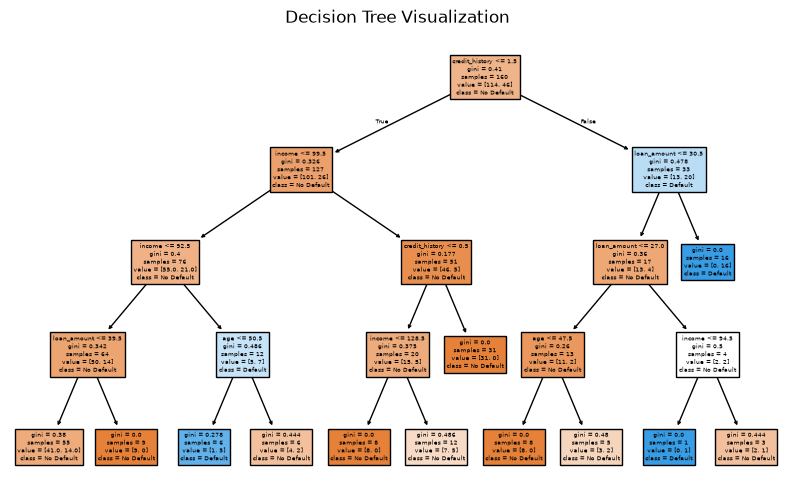

In [ ]:
plt.figure(figsize=(10, 6))
plot_tree(dt_classifier, filled=True, feature_names=X.columns, class_names=['No Default', 'Default'])
plt.title("Decision Tree Visualization")
plt.show()